In [1]:
!pip install keras tensorflow pillow matplotlib opencv-python --quiet

In [2]:
import keras

MODEL_PATH = 'Camouflaged_UNET_final.keras'
model = keras.models.load_model(MODEL_PATH)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │     36,928 │ dropout_2[0][0] 

 Total params: 5,835,093 (22.26 MB)

 Trainable params: 1,944,049 (7.42 MB)

 Non-trainable params: 2,944 (11.50 KB)

 Optimizer params: 3,888,100 (14.83 MB)

In [3]:
import numpy as np
from PIL import Image

IMAGE_PATH = 'image10.jpg'   # ← change to your filename

img_pil     = Image.open(IMAGE_PATH).convert('RGB')
orig_size   = img_pil.size                              # save original (W, H)
img_resized = img_pil.resize((224, 224), Image.BILINEAR)
arr         = np.array(img_resized, dtype=np.float32) / 255.0
batch       = np.expand_dims(arr, axis=0)               # shape: (1,224,224,3)

print('Input batch shape:', batch.shape)
print('Pixel range:', batch.min(), '→', batch.max())

Input batch shape: (1, 224, 224, 3)
Pixel range: 0.003921569 → 0.8784314


In [4]:
pred     = model.predict(batch, verbose=1)
mask_224 = pred[0, :, :, 0]    # squeeze out batch & channel dims

print('Prediction shape:', pred.shape)
print('Mask value range:', mask_224.min().round(3), '→', mask_224.max().round(3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction shape: (1, 224, 224, 1)
Mask value range: 0.0 → 0.759


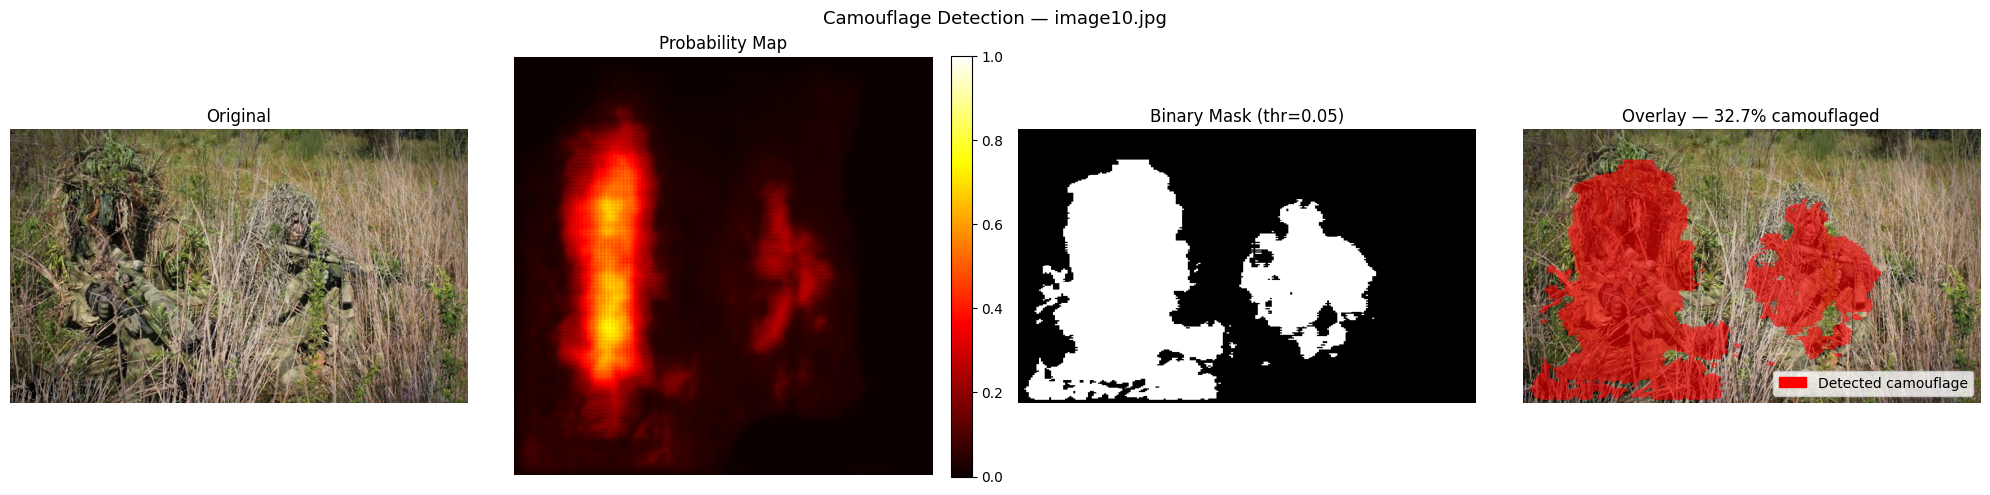

Camouflaged area: 32.69%


In [5]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

THRESHOLD = 0.05   # adjust later if needed

# Binary mask at original resolution
mask_bin_small = (mask_224 > THRESHOLD).astype(np.uint8)
W, H     = orig_size
mask_bin = cv2.resize(mask_bin_small, (W, H), interpolation=cv2.INTER_NEAREST)
pct      = 100.0 * mask_bin.sum() / mask_bin.size

# Red overlay
orig_arr = np.array(img_pil)
overlay  = orig_arr.copy()
overlay[mask_bin == 1] = (overlay[mask_bin == 1] * 0.4 + np.array([255,0,0]) * 0.6).astype(np.uint8)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Camouflage Detection — {IMAGE_PATH}', fontsize=13)

axes[0].imshow(orig_arr);            axes[0].set_title('Original');       axes[0].axis('off')
im = axes[1].imshow(mask_224, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('Probability Map'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[2].imshow(mask_bin, cmap='gray'); axes[2].set_title(f'Binary Mask (thr={THRESHOLD})'); axes[2].axis('off')
axes[3].imshow(overlay);             axes[3].set_title(f'Overlay — {pct:.1f}% camouflaged'); axes[3].axis('off')

red = mpatches.Patch(color='red', label='Detected camouflage')
axes[3].legend(handles=[red], loc='lower right')
plt.tight_layout()
plt.savefig('detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Camouflaged area: {pct:.2f}%')

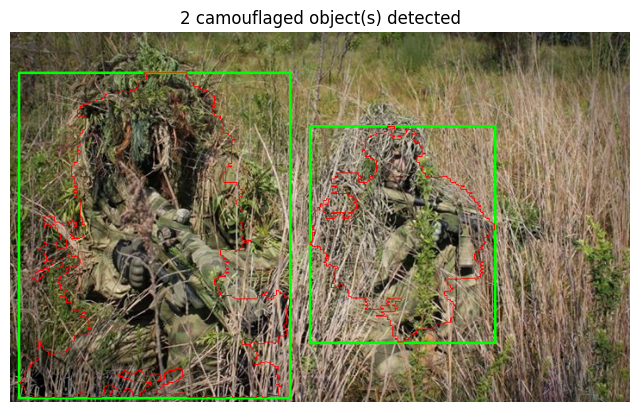

In [6]:
contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_boxes   = orig_arr.copy()
count = 0

for cnt in contours:
    if cv2.contourArea(cnt) < 200:   # skip tiny noise
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_boxes, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.drawContours(img_boxes, [cnt], -1, (255,0,0), 1)
    count += 1

plt.figure(figsize=(8,6))
plt.imshow(img_boxes)
plt.title(f'{count} camouflaged object(s) detected')
plt.axis('off')
plt.show()

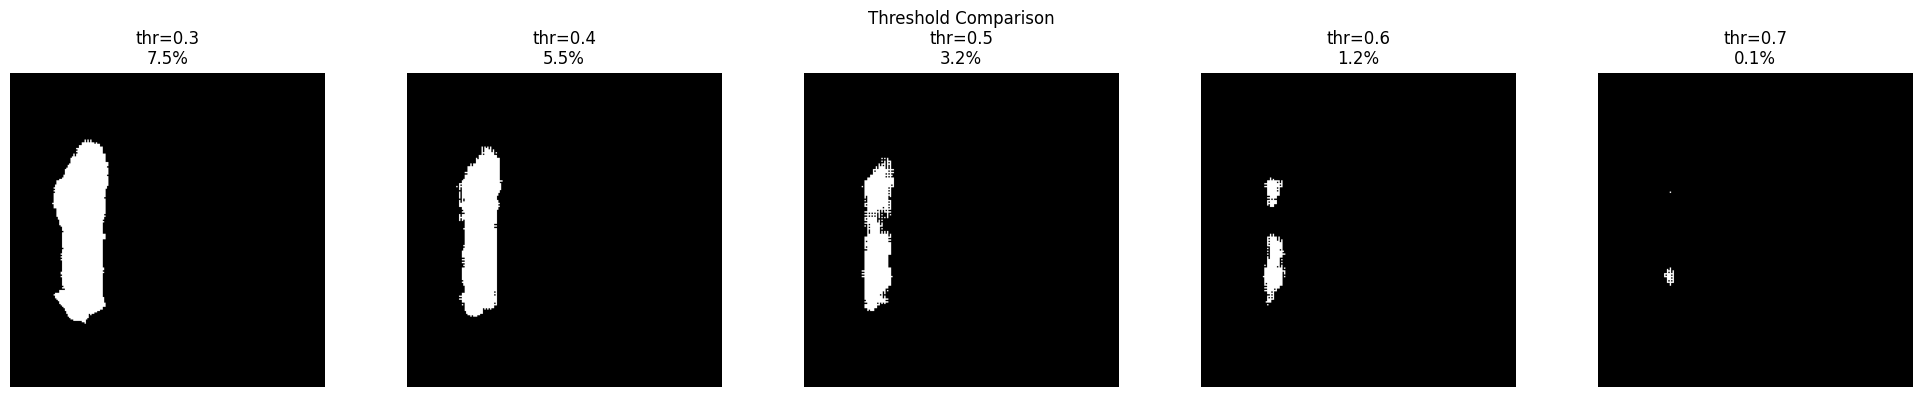

In [7]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
fig, axes  = plt.subplots(1, 5, figsize=(20, 4))

for ax, thr in zip(axes, thresholds):
    m   = (mask_224 > thr).astype(np.uint8)
    pct = 100.0 * m.sum() / m.size
    ax.imshow(m, cmap='gray')
    ax.set_title(f'thr={thr}\n{pct:.1f}%')
    ax.axis('off')

plt.suptitle('Threshold Comparison')
plt.tight_layout()
plt.show()

In [ ]:
import os
from pathlib import Path

IMAGE_DIR  = '/content/'           # Colab upload folder
OUTPUT_DIR = 'output_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
images = [p for p in Path(IMAGE_DIR).iterdir() if p.suffix.lower() in EXTS]
print(f'Found {len(images)} image(s)')

for img_path in images:
    img_pil     = Image.open(img_path).convert('RGB')
    orig_size   = img_pil.size
    arr         = np.array(img_pil.resize((224,224), Image.BILINEAR), dtype=np.float32) / 255.0
    pred        = model.predict(np.expand_dims(arr, 0), verbose=0)
    mask_224    = pred[0,:,:,0]
    mask_bin    = cv2.resize((mask_224 > 0.5).astype(np.uint8), orig_size, interpolation=cv2.INTER_NEAREST)
    pct         = 100.0 * mask_bin.sum() / mask_bin.size

    Image.fromarray(mask_bin * 255).save(f'{OUTPUT_DIR}/{img_path.stem}_mask.png')
    print(f'{img_path.name}: {pct:.2f}% camouflaged')

print('Done!')

Found 2 image(s)
image10.jpg: 3.21% camouflaged
detection_result.png: 48.45% camouflaged
Done!
